In [543]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.metrics import r2_score

In [486]:
df = pd.read_csv('day.csv')

In [487]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [488]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


## Removing the unwanted columns

- instant - serial number
- dteday - as month and year columns are there
- casual & registered - cannot be really used ofr predicting

In [489]:
df.drop(columns=["instant","dteday","casual","registered"],axis=1,inplace =True)
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,985
1,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,801
2,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,1349
3,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,1562
4,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,1600


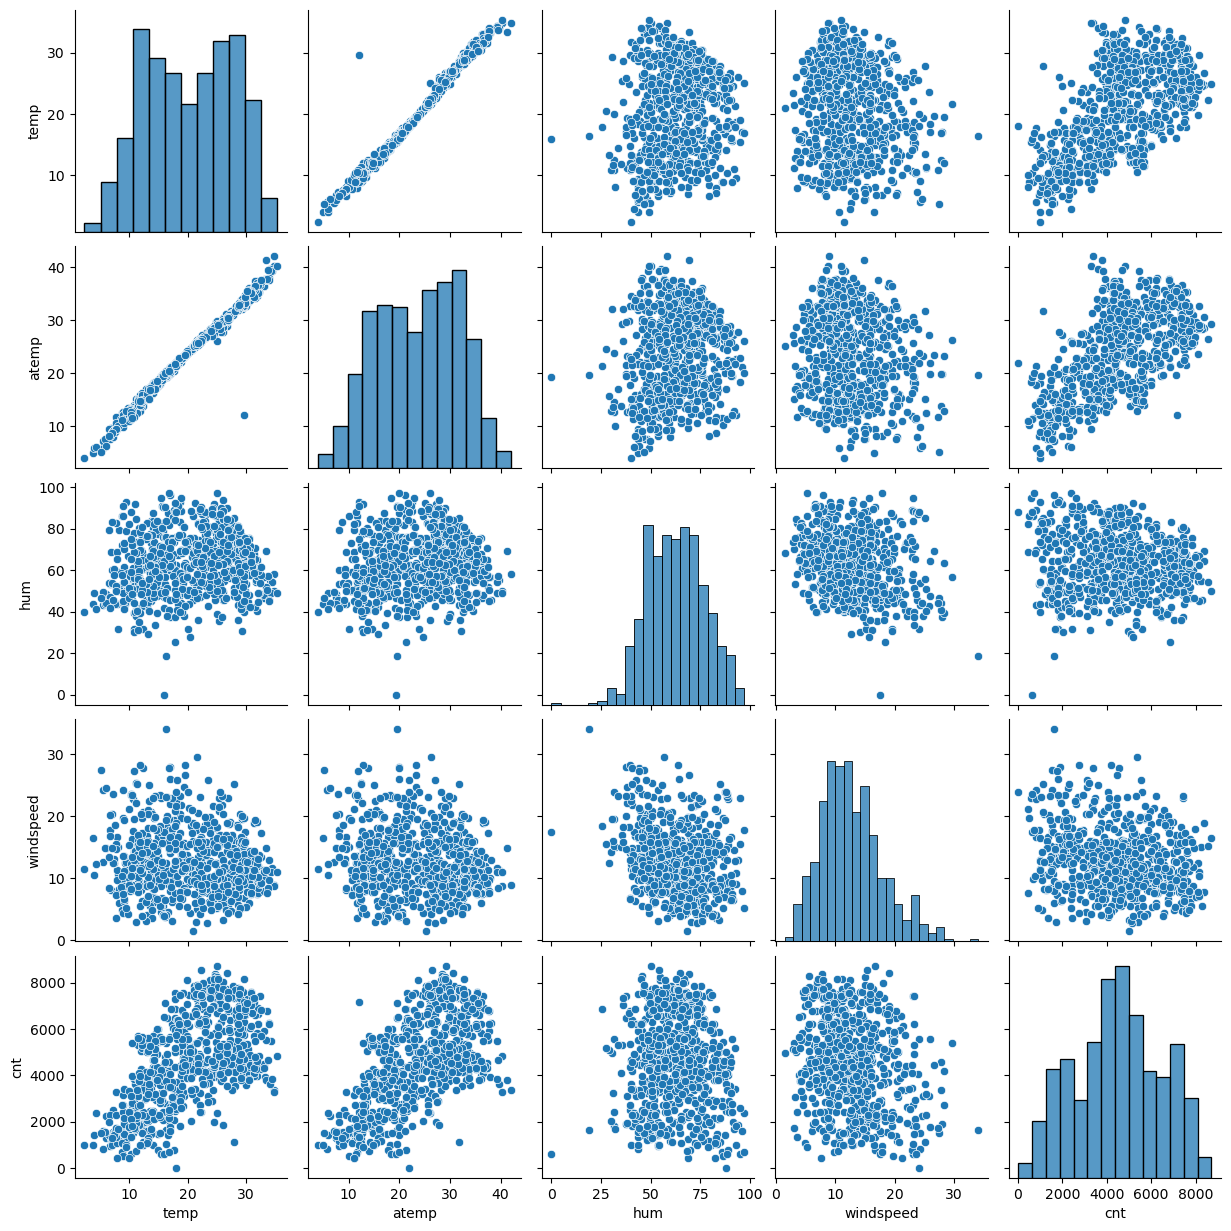

In [490]:
sns.pairplot(df[["temp","atemp","hum","windspeed","cnt"]])
plt.show()


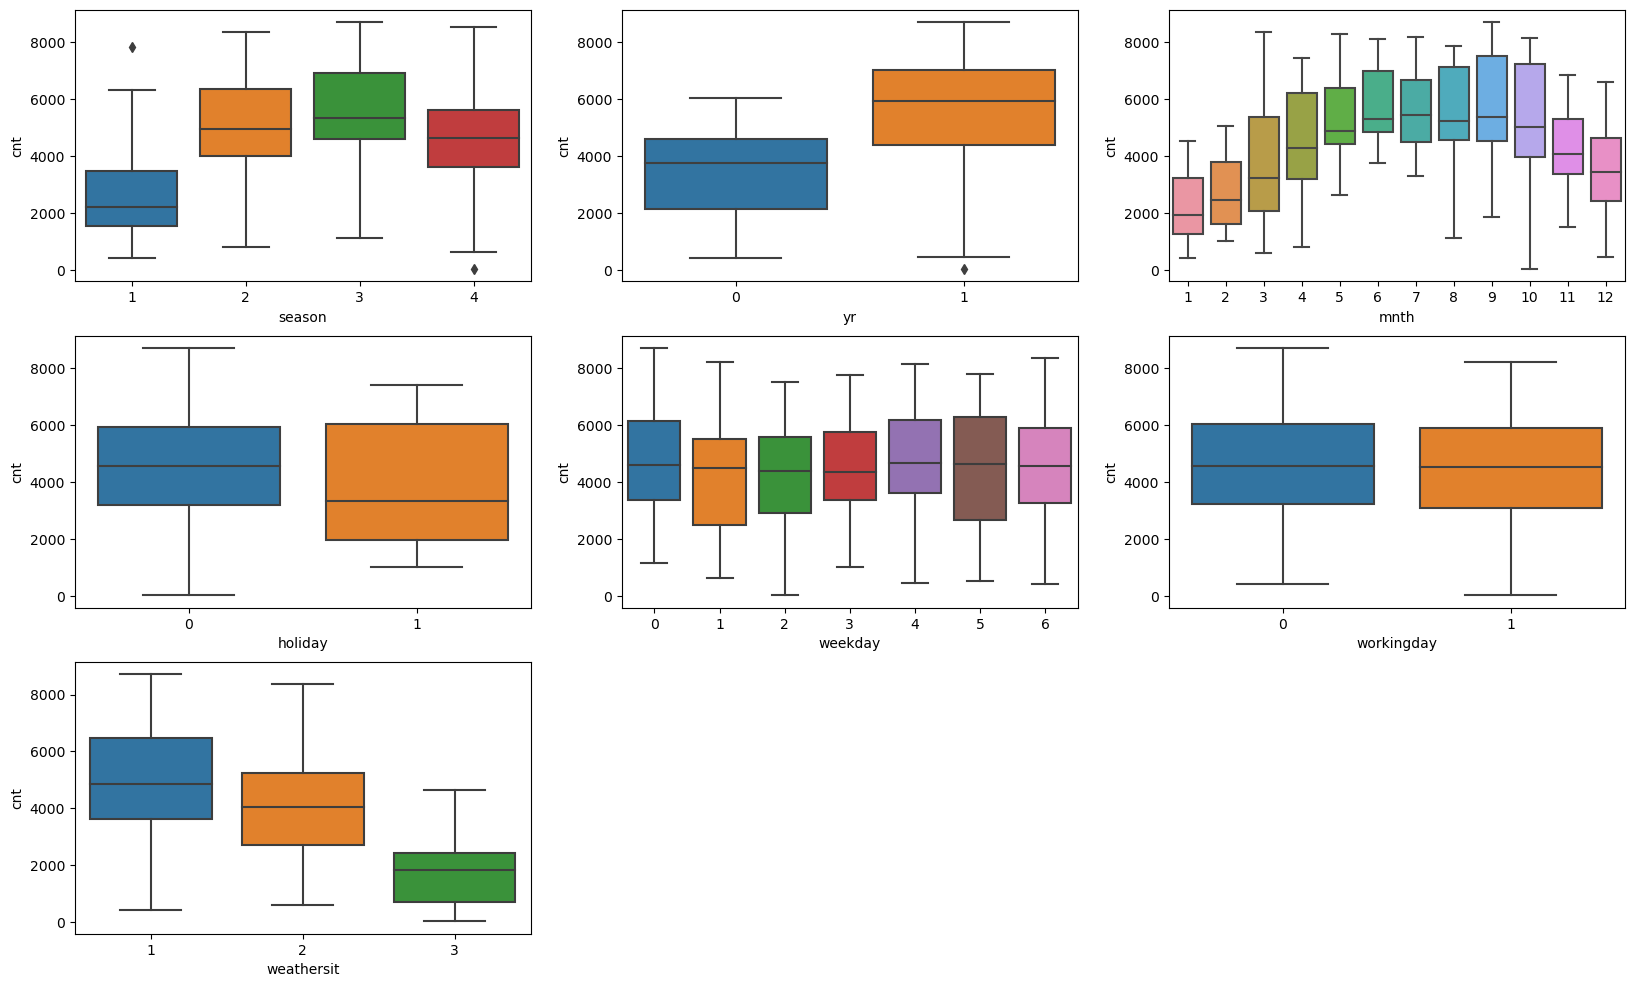

In [491]:
plt.figure(figsize=(20, 12))
plt.subplot(3,3,1)
sns.boxplot(x = 'season', y = 'cnt', data = df)
plt.subplot(3,3,2)
sns.boxplot(x = 'yr', y = 'cnt', data = df)
plt.subplot(3,3,3)
sns.boxplot(x = 'mnth', y = 'cnt', data = df)
plt.subplot(3,3,4)
sns.boxplot(x = 'holiday', y = 'cnt', data = df)
plt.subplot(3,3,5)
sns.boxplot(x = 'weekday', y = 'cnt', data = df)
plt.subplot(3,3,6)
sns.boxplot(x = 'workingday', y = 'cnt', data = df)
plt.subplot(3,3,7)
sns.boxplot(x = 'weathersit', y = 'cnt', data = df)
plt.show()

## Creating the dummy variables

In [492]:
season = pd.get_dummies(df['season'])
season.rename(columns = {1: "spring", 2: "summer", 3: "fall"}, inplace = True)
season.drop(columns = 4, axis = 1, inplace = True)
season.head()

,spring,summer,fall
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [493]:
weather = pd.get_dummies(df['weathersit'])
weather.rename(columns = {1: "No_rain", 2: "Likely_rain", 3: "Light_Rain"}, inplace = True)

weather.head()

,No_rain,Likely_rain,Light_Rain
0,0,1,0
1,0,1,0
2,1,0,0
3,1,0,0
4,1,0,0


### concatenating the dummy variable

In [494]:
df1 = pd.concat([df,season,weather],axis = 1)
df1.drop(columns = ["season", "weathersit"], axis=1, inplace = True)

In [495]:
df1.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,cnt,spring,summer,fall,No_rain,Likely_rain,Light_Rain
0,0,1,0,1,1,14.110847,18.18125,80.5833,10.749882,985,1,0,0,0,1,0
1,0,1,0,2,1,14.902598,17.68695,69.6087,16.652113,801,1,0,0,0,1,0
2,0,1,0,3,1,8.050924,9.47025,43.7273,16.636703,1349,1,0,0,1,0,0
3,0,1,0,4,1,8.200000,10.60610,59.0435,10.739832,1562,1,0,0,1,0,0
4,0,1,0,5,1,9.305237,11.46350,43.6957,12.522300,1600,1,0,0,1,0,0


### Spliting the year into 3 quaters

In [496]:
df1["JanFebMar"] = df1["mnth"].apply(lambda x: 1 if x<=3 else 0)
df1["AprMayJun"] = df1["mnth"].apply(lambda x: 1 if 4<=x<=6 else 0)
df1["JulAugSep"] = df1["mnth"].apply(lambda x: 1 if 7<=x<=9 else 0)

In [497]:
df1.head()

,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,cnt,spring,summer,fall,No_rain,Likely_rain,Light_Rain,JanFebMar,AprMayJun,JulAugSep
0,0,1,0,1,1,14.110847,18.18125,80.5833,10.749882,985,1,0,0,0,1,0,1,0,0
1,0,1,0,2,1,14.902598,17.68695,69.6087,16.652113,801,1,0,0,0,1,0,1,0,0
2,0,1,0,3,1,8.050924,9.47025,43.7273,16.636703,1349,1,0,0,1,0,0,1,0,0
3,0,1,0,4,1,8.200000,10.60610,59.0435,10.739832,1562,1,0,0,1,0,0,1,0,0
4,0,1,0,5,1,9.305237,11.46350,43.6957,12.522300,1600,1,0,0,1,0,0,1,0,0


In [498]:
df1.drop(columns = ["mnth"], axis = 1, inplace = True)

In [499]:
df1["weekend"] = df1["weekday"].apply(lambda x: 0 if 1<=x<=5 else 1)
df1.drop(columns = ["weekday"],axis=1,inplace =True)
df1.drop(columns = ["workingday"],axis=1,inplace =True)
df1.head()

,yr,holiday,temp,atemp,hum,windspeed,cnt,spring,summer,fall,No_rain,Likely_rain,Light_Rain,JanFebMar,AprMayJun,JulAugSep,weekend
0,0,0,14.110847,18.18125,80.5833,10.749882,985,1,0,0,0,1,0,1,0,0,0
1,0,0,14.902598,17.68695,69.6087,16.652113,801,1,0,0,0,1,0,1,0,0,0
2,0,0,8.050924,9.47025,43.7273,16.636703,1349,1,0,0,1,0,0,1,0,0,0
3,0,0,8.200000,10.60610,59.0435,10.739832,1562,1,0,0,1,0,0,1,0,0,0
4,0,0,9.305237,11.46350,43.6957,12.522300,1600,1,0,0,1,0,0,1,0,0,0


In [500]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   yr           730 non-null    int64  
 1   holiday      730 non-null    int64  
 2   temp         730 non-null    float64
 3   atemp        730 non-null    float64
 4   hum          730 non-null    float64
 5   windspeed    730 non-null    float64
 6   cnt          730 non-null    int64  
 7   spring       730 non-null    uint8  
 8   summer       730 non-null    uint8  
 9   fall         730 non-null    uint8  
 10  No_rain      730 non-null    uint8  
 11  Likely_rain  730 non-null    uint8  
 12  Light_Rain   730 non-null    uint8  
 13  JanFebMar    730 non-null    int64  
 14  AprMayJun    730 non-null    int64  
 15  JulAugSep    730 non-null    int64  
 16  weekend      730 non-null    int64  
dtypes: float64(4), int64(7), uint8(6)
memory usage: 67.1 KB


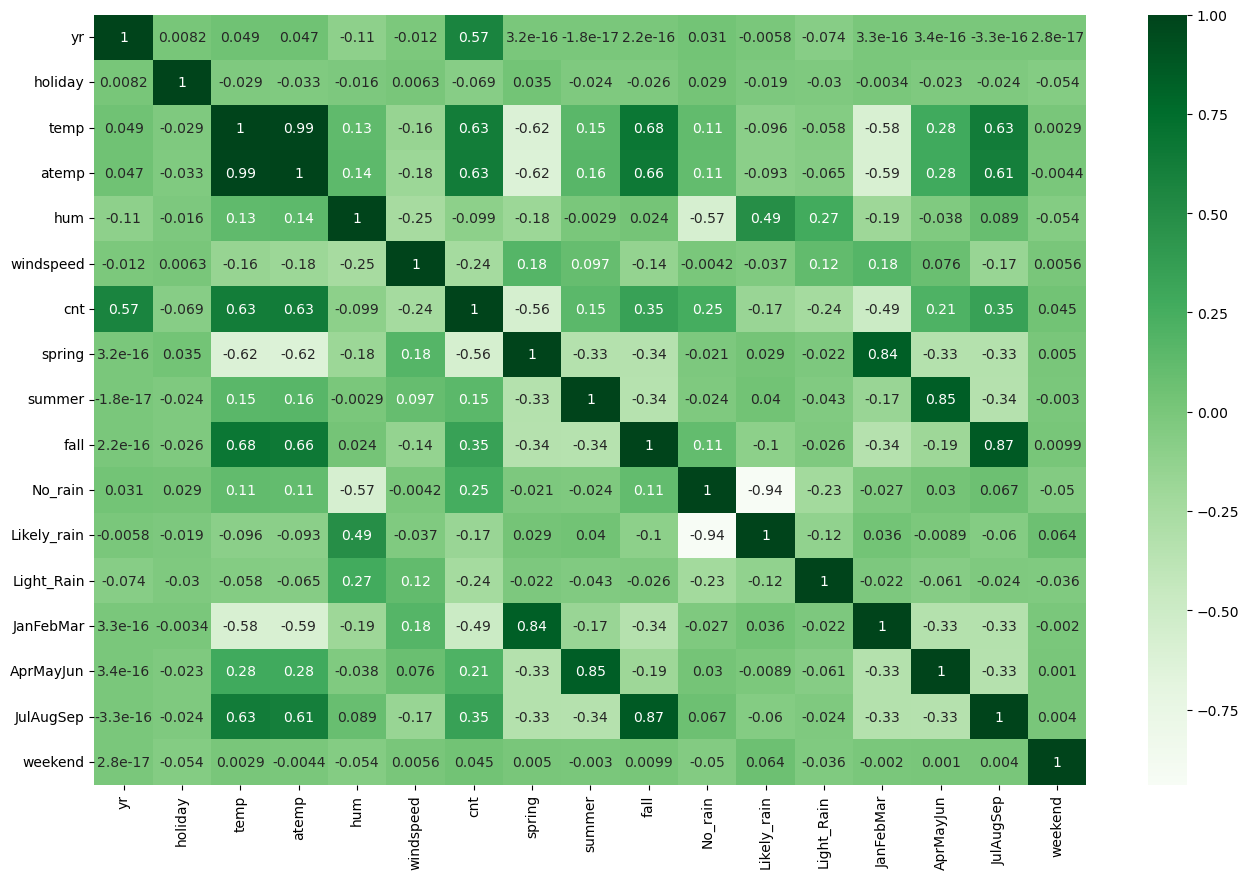

In [501]:
plt.figure(figsize = (16, 10))
sns.heatmap(df1.corr(), annot = True, cmap="Greens")
plt.show()

### Droping temp as it is very highly co-linear with atemp, and atemp i.e. feeling temp is much more relevant.


In [502]:
df1.drop(columns = ["temp"], axis = 1, inplace = True)
df1.head()

,yr,holiday,atemp,hum,windspeed,cnt,spring,summer,fall,No_rain,Likely_rain,Light_Rain,JanFebMar,AprMayJun,JulAugSep,weekend
0,0,0,18.18125,80.5833,10.749882,985,1,0,0,0,1,0,1,0,0,0
1,0,0,17.68695,69.6087,16.652113,801,1,0,0,0,1,0,1,0,0,0
2,0,0,9.47025,43.7273,16.636703,1349,1,0,0,1,0,0,1,0,0,0
3,0,0,10.60610,59.0435,10.739832,1562,1,0,0,1,0,0,1,0,0,0
4,0,0,11.46350,43.6957,12.522300,1600,1,0,0,1,0,0,1,0,0,0


# Building Linear Models

### Splitting the data into 70% train and 30% test

In [503]:
df_train, df_test = train_test_split(df1, train_size = 0.7, test_size = 0.3, random_state = 100)

In [504]:
numeric_var = ['atemp','hum','windspeed','cnt']
df_train[numeric_var] = scaler.fit_transform(df_train[numeric_var])

In [505]:
df_train.head()

,yr,holiday,atemp,hum,windspeed,cnt,spring,summer,fall,No_rain,Likely_rain,Light_Rain,JanFebMar,AprMayJun,JulAugSep,weekend
653,1,0,0.501133,0.575354,0.300794,0.864243,0,0,0,1,0,0,0,0,0,0
576,1,0,0.766351,0.725633,0.264686,0.827658,0,0,1,1,0,0,0,0,1,0
426,1,0,0.438975,0.640189,0.255342,0.465255,1,0,0,0,1,0,1,0,0,1
728,1,0,0.200348,0.498067,0.663106,0.204096,1,0,0,1,0,0,0,0,0,0
482,1,0,0.391735,0.504508,0.188475,0.482973,0,1,0,0,1,0,0,1,0,1


In [506]:
y_train = df_train.pop('cnt')
y_train.head()

653    0.864243
576    0.827658
426    0.465255
728    0.204096
482    0.482973
Name: cnt, dtype: float64

In [507]:
X_train = df_train
X_train.head()

,yr,holiday,atemp,hum,windspeed,spring,summer,fall,No_rain,Likely_rain,Light_Rain,JanFebMar,AprMayJun,JulAugSep,weekend
653,1,0,0.501133,0.575354,0.300794,0,0,0,1,0,0,0,0,0,0
576,1,0,0.766351,0.725633,0.264686,0,0,1,1,0,0,0,0,1,0
426,1,0,0.438975,0.640189,0.255342,1,0,0,0,1,0,1,0,0,1
728,1,0,0.200348,0.498067,0.663106,1,0,0,1,0,0,0,0,0,0
482,1,0,0.391735,0.504508,0.188475,0,1,0,0,1,0,0,1,0,1


## 1 st model with all the variables

In [508]:
X_train_sm = sm.add_constant(X_train)

lr = sm.OLS(y_train,X_train_sm)

lr_model = lr.fit()

lr_model.params

const          0.207282
yr             0.231599
holiday       -0.079046
atemp          0.466194
hum           -0.129255
windspeed     -0.160436
spring        -0.191365
summer        -0.082954
fall          -0.137899
No_rain        0.168415
Likely_rain    0.109272
Light_Rain    -0.070405
JanFebMar      0.032485
AprMayJun      0.055662
JulAugSep      0.087485
weekend        0.020833
dtype: float64

In [509]:
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     170.9
Date:                Tue, 04 Jul 2023   Prob (F-statistic):          3.03e-179
Time:                        23:12:54   Log-Likelihood:                 488.24
No. Observations:                 510   AIC:                            -946.5
Df Residuals:                     495   BIC:                            -883.0
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.2073      0.027      7.652      0.000       0.154       0.261
yr              0.2316      0.008     27.296      0.000       0.215       0.248
holiday        -0.0790      0.027     -2.959      0.003      -0.132      -0.027
atemp           0.4662      0.038     12.380      0.000       0.392       0.540
hum            -0.1293      0.040     -3.260      0.001      -0.207      -0.051
windspeed      -0.1604      0.027     -5.955      0.000      -0.213      -0.108
spring         -0.1914      0.025     -7.767      0.000      -0.240      -0.143
summer         -0.0830      0.028     -2.986      0.003      -0.138      -0.028
fall           -0.1379      0.027     -5.079      0.000      -0.191      -0.085
No_rain         0.1684      0.009     17.783      0.000       0.150       0.187
Likely_rain     0.1093      0.012      8.802      0.000       0.085       0.134
Light_Rain     -0.0704      0.023     -3.074      0.002      -0.115      -0.025
JanFebMar       0.0325      0.024      1.343      0.180      -0.015       0.080
AprMayJun       0.0557      0.029      1.933      0.054      -0.001       0.112
JulAugSep       0.0875      0.027      3.193      0.001       0.034       0.141
weekend         0.0208      0.010      2.186      0.029       0.002       0.040
==============================================================================
Omnibus:                       71.548   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              184.364
Skew:                          -0.708   Prob(JB):                     9.25e-41
Kurtosis:                       5.583   Cond. No.                     1.96e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.09e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

## Checking the VIF of the variables

In [510]:
vif = pd.DataFrame()
X = X_train
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
8,No_rain,35.05
9,Likely_rain,25.81
12,AprMayJun,8.61
6,summer,8.19
7,fall,8.19
13,JulAugSep,8.14
5,spring,6.41
11,JanFebMar,6.34
2,atemp,3.66
10,Light_Rain,3.63


In [511]:
X = X_train.drop(columns = 'No_rain', axis = 1)

## 2nd model ( Dropping 'No_rain')

In [512]:
X_train_sm = sm.add_constant(X)

lr = sm.OLS(y_train,X_train_sm)

lr_model = lr.fit()

lr_model.params

const          0.375696
yr             0.231599
holiday       -0.079046
atemp          0.466194
hum           -0.129255
windspeed     -0.160436
spring        -0.191365
summer        -0.082954
fall          -0.137899
Likely_rain   -0.059143
Light_Rain    -0.238819
JanFebMar      0.032485
AprMayJun      0.055662
JulAugSep      0.087485
weekend        0.020833
dtype: float64

In [513]:
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     170.9
Date:                Tue, 04 Jul 2023   Prob (F-statistic):          3.03e-179
Time:                        23:12:56   Log-Likelihood:                 488.24
No. Observations:                 510   AIC:                            -946.5
Df Residuals:                     495   BIC:                            -883.0
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.3757      0.031     12.038      0.000       0.314       0.437
yr              0.2316      0.008     27.296      0.000       0.215       0.248
holiday        -0.0790      0.027     -2.959      0.003      -0.132      -0.027
atemp           0.4662      0.038     12.380      0.000       0.392       0.540
hum            -0.1293      0.040     -3.260      0.001      -0.207      -0.051
windspeed      -0.1604      0.027     -5.955      0.000      -0.213      -0.108
spring         -0.1914      0.025     -7.767      0.000      -0.240      -0.143
summer         -0.0830      0.028     -2.986      0.003      -0.138      -0.028
fall           -0.1379      0.027     -5.079      0.000      -0.191      -0.085
Likely_rain    -0.0591      0.011     -5.338      0.000      -0.081      -0.037
Light_Rain     -0.2388      0.028     -8.640      0.000      -0.293      -0.185
JanFebMar       0.0325      0.024      1.343      0.180      -0.015       0.080
AprMayJun       0.0557      0.029      1.933      0.054      -0.001       0.112
JulAugSep       0.0875      0.027      3.193      0.001       0.034       0.141
weekend         0.0208      0.010      2.186      0.029       0.002       0.040
==============================================================================
Omnibus:                       71.548   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              184.364
Skew:                          -0.708   Prob(JB):                     9.25e-41
Kurtosis:                       5.583   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [514]:
vif = pd.DataFrame()
#X = X_train
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,atemp,22.53
3,hum,17.57
11,AprMayJun,11.29
7,fall,11.11
12,JulAugSep,10.87
6,summer,10.85
10,JanFebMar,8.40
5,spring,8.33
4,windspeed,4.15
8,Likely_rain,2.18


### 3rd model -- dropping No_rain and atemp

In [515]:
X = X_train.drop(columns = ['No_rain', 'atemp'], axis = 1)

In [516]:
X_train_sm = sm.add_constant(X)

lr = sm.OLS(y_train,X_train_sm)

lr_model = lr.fit()

lr_model.params
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     131.8
Date:                Tue, 04 Jul 2023   Prob (F-statistic):          1.72e-151
Time:                        23:12:58   Log-Likelihood:                 419.46
No. Observations:                 510   AIC:                            -810.9
Df Residuals:                     496   BIC:                            -751.6
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.4986      0.034     14.739      0.000       0.432       0.565
yr              0.2442      0.010     25.364      0.000       0.225       0.263
holiday        -0.0860      0.031     -2.816      0.005      -0.146      -0.026
hum            -0.0094      0.044     -0.214      0.831      -0.096       0.077
windspeed      -0.1688      0.031     -5.483      0.000      -0.229      -0.108
spring         -0.2489      0.028     -8.999      0.000      -0.303      -0.195
summer         -0.0938      0.032     -2.956      0.003      -0.156      -0.031
fall           -0.0681      0.030     -2.243      0.025      -0.128      -0.008
Likely_rain    -0.0873      0.012     -7.044      0.000      -0.112      -0.063
Light_Rain     -0.2795      0.031     -8.907      0.000      -0.341      -0.218
JanFebMar       0.0358      0.028      1.296      0.195      -0.018       0.090
AprMayJun       0.1490      0.032      4.689      0.000       0.087       0.211
JulAugSep       0.1683      0.030      5.532      0.000       0.109       0.228
weekend         0.0228      0.011      2.093      0.037       0.001       0.044
==============================================================================
Omnibus:                       29.607   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               75.755
Skew:                          -0.248   Prob(JB):                     3.55e-17
Kurtosis:                       4.822   Cond. No.                         19.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [517]:
vif = pd.DataFrame()
#X = X_train
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
5,summer,10.84
6,fall,10.57
10,AprMayJun,10.42
11,JulAugSep,10.26
9,JanFebMar,8.38
4,spring,8.12
2,hum,7.20
3,windspeed,4.05
0,yr,1.98
7,Likely_rain,1.94


# Now building model use RFE

In [518]:
rfe = RFE(lm)             # running RFE
rfe = rfe.fit(X_train, y_train)

In [519]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('yr', True, 1),
 ('holiday', True, 1),
 ('atemp', True, 1),
 ('hum', True, 1),
 ('windspeed', True, 1),
 ('spring', True, 1),
 ('summer', False, 6),
 ('fall', False, 2),
 ('No_rain', False, 4),
 ('Likely_rain', False, 5),
 ('Light_Rain', True, 1),
 ('JanFebMar', False, 8),
 ('AprMayJun', False, 7),
 ('JulAugSep', False, 3),
 ('weekend', False, 9)]

In [520]:
col = X_train.columns[rfe.support_]
col

Index(['yr', 'holiday', 'atemp', 'hum', 'windspeed', 'spring', 'Light_Rain'], dtype='object')

In [521]:
X_train_rfe = X_train[col]

In [522]:


lr = sm.OLS(y_train,X_train_rfe)

lr_model = lr.fit()

lr_model.params
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    cnt   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1587.
Date:                Tue, 04 Jul 2023   Prob (F-statistic):                        0.00
Time:                        23:12:58   Log-Likelihood:                          372.08
No. Observations:                 510   AIC:                                     -730.2
Df Residuals:                     503   BIC:                                     -700.5
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
yr             0.2525      0.010     24.309      0.000       0.232       0.273
holiday       -0.0510      0.033     -1.544      0.123      -0.116       0.014
atemp          0.6035      0.028     21.868      0.000       0.549       0.658
hum            0.1367      0.025      5.477      0.000       0.088       0.186
windspeed      0.0172      0.028      0.614      0.540      -0.038       0.072
spring        -0.0776      0.014     -5.509      0.000      -0.105      -0.050
Light_Rain    -0.2532      0.032     -7.930      0.000      -0.316      -0.190
==============================================================================
Omnibus:                       49.231   Durbin-Watson:                   2.024
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               71.547
Skew:                          -0.686   Prob(JB):                     2.91e-16
Kurtosis:                       4.218   Cond. No.                         8.02
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [523]:
vif = pd.DataFrame()
X = X_train[col]
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
3,hum,10.22
2,atemp,8.68
4,windspeed,3.82
0,yr,2.03
5,spring,1.78
6,Light_Rain,1.11
1,holiday,1.03


In [524]:
X_train_rfe.head()

,yr,holiday,atemp,hum,windspeed,spring,Light_Rain
653,1,0,0.501133,0.575354,0.300794,0,0
576,1,0,0.766351,0.725633,0.264686,0,0
426,1,0,0.438975,0.640189,0.255342,1,0
728,1,0,0.200348,0.498067,0.663106,1,0
482,1,0,0.391735,0.504508,0.188475,0,0


In [525]:
X_train_new = X_train_rfe.drop(['hum'],axis = 1)

In [526]:
lr = sm.OLS(y_train,X_train_new)

lr_model = lr.fit()

lr_model.params
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    cnt   R-squared (uncentered):                   0.954
Model:                            OLS   Adj. R-squared (uncentered):              0.954
Method:                 Least Squares   F-statistic:                              1746.
Date:                Tue, 04 Jul 2023   Prob (F-statistic):                        0.00
Time:                        23:12:59   Log-Likelihood:                          357.31
No. Observations:                 510   AIC:                                     -702.6
Df Residuals:                     504   BIC:                                     -677.2
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
yr             0.2559      0.011     23.997      0.000       0.235       0.277
holiday       -0.0421      0.034     -1.241      0.215      -0.109       0.025
atemp          0.7223      0.018     41.123      0.000       0.688       0.757
windspeed      0.0554      0.028      1.985      0.048       0.001       0.110
spring        -0.0465      0.013     -3.508      0.000      -0.073      -0.020
Light_Rain    -0.2116      0.032     -6.634      0.000      -0.274      -0.149
==============================================================================
Omnibus:                       42.682   Durbin-Watson:                   2.055
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.231
Skew:                          -0.631   Prob(JB):                     1.37e-13
Kurtosis:                       4.093   Cond. No.                         5.82
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [527]:
vif = pd.DataFrame()
X = X_train_new
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
3,windspeed,3.59
2,atemp,3.32
0,yr,2.02
4,spring,1.49
5,Light_Rain,1.05
1,holiday,1.03


### So this can be pur final model where the p-values are significanltly low i.e. below 0.05 and vif is low i.e. below 5.µ

In [528]:
y_train_pred = lr_model.predict(X)
y_train_pred.head()

653    0.634538
576    0.824099
426    0.540647
728    0.390893
482    0.549296
dtype: float64

In [529]:
res = y_train - y_train_pred


/Users/vivek/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


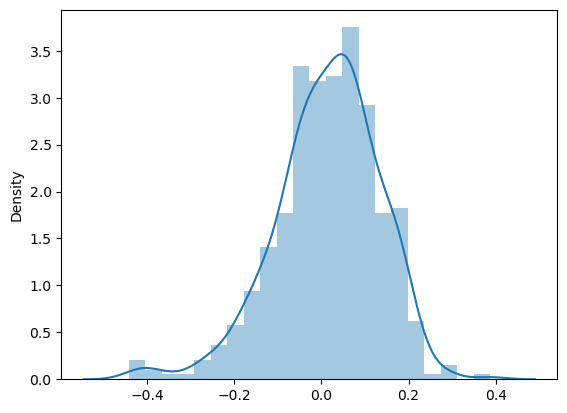

In [530]:
sns.distplot(res)
plt.show()

# Presictions and evaluation

In [479]:
df_test.head()

,yr,holiday,atemp,hum,windspeed,cnt,spring,summer,fall,No_rain,Likely_rain,Light_Rain,JanFebMar,AprMayJun,JulAugSep,weekend
184,0,1,33.27085,63.7917,5.459106,6043,0,0,1,0,1,0,0,0,1,0
535,1,0,36.04875,59.2083,7.625404,6211,0,1,0,1,0,0,0,1,0,0
299,0,0,22.85230,81.2917,13.250121,2659,0,0,0,0,1,0,0,0,0,1
221,0,0,34.24915,42.4167,13.417286,4780,0,0,1,1,0,0,0,0,1,0
152,0,0,32.19710,30.5000,19.583229,4968,0,1,0,1,0,0,0,1,0,1


In [531]:
df_test[numeric_var] = scaler.transform(df_test[numeric_var])


In [532]:
df_test.head()

,yr,holiday,atemp,hum,windspeed,cnt,spring,summer,fall,No_rain,Likely_rain,Light_Rain,JanFebMar,AprMayJun,JulAugSep,weekend
184,0,1,0.769660,0.657364,0.084219,0.692706,0,0,1,0,1,0,0,0,1,0
535,1,0,0.842587,0.610133,0.153728,0.712034,0,1,0,1,0,0,0,1,0,0
299,0,0,0.496145,0.837699,0.334206,0.303382,0,0,0,0,1,0,0,0,0,1
221,0,0,0.795343,0.437098,0.339570,0.547400,0,0,1,1,0,0,0,0,1,0
152,0,0,0.741471,0.314298,0.537414,0.569029,0,1,0,1,0,0,0,1,0,1


In [534]:
y_test = df_test.pop('cnt')
X_test = df_test

In [535]:
X_test_sm = sm.add_constant(X_test)
X_test_sm.head()

,const,yr,holiday,atemp,hum,windspeed,spring,summer,fall,No_rain,Likely_rain,Light_Rain,JanFebMar,AprMayJun,JulAugSep,weekend
184,1.0,0,1,0.769660,0.657364,0.084219,0,0,1,0,1,0,0,0,1,0
535,1.0,1,0,0.842587,0.610133,0.153728,0,1,0,1,0,0,0,1,0,0
299,1.0,0,0,0.496145,0.837699,0.334206,0,0,0,0,1,0,0,0,0,1
221,1.0,0,0,0.795343,0.437098,0.339570,0,0,1,1,0,0,0,0,1,0
152,1.0,0,0,0.741471,0.314298,0.537414,0,1,0,1,0,0,0,1,0,1


In [537]:
X_test_sm = X_test_sm[col]

In [538]:
X_test_sm.head()

,yr,holiday,atemp,hum,windspeed,spring,Light_Rain
184,0,1,0.769660,0.657364,0.084219,0,0
535,1,0,0.842587,0.610133,0.153728,0,0
299,0,0,0.496145,0.837699,0.334206,0,0
221,0,0,0.795343,0.437098,0.339570,0,0
152,0,0,0.741471,0.314298,0.537414,0,0


In [540]:
X_test_sm = X_test_sm.drop('hum', axis = 1)

In [541]:
X_test_sm.head()


,yr,holiday,atemp,windspeed,spring,Light_Rain
184,0,1,0.769660,0.084219,0,0
535,1,0,0.842587,0.153728,0,0
299,0,0,0.496145,0.334206,0,0
221,0,0,0.795343,0.339570,0,0
152,0,0,0.741471,0.537414,0,0


In [542]:
y_test_pred = lr_model.predict(X_test_sm)

In [544]:
r2_score (y_true = y_test, y_pred = y_test_pred)

0.702151565438695